In [31]:
# Cell 1 - Install dependencies
!pip install xgboost scikit-learn pandas numpy matplotlib seaborn -q

In [32]:
# Cell 2 - Import all libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score, roc_curve)
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [33]:
# Cell 3 - Load Heart Disease Dataset (UCI)
url_heart = "https://raw.githubusercontent.com/dsrscientist/dataset1/master/heart_disease.csv"
df_heart = pd.read_csv(url_heart)
print("❤️ Heart Disease Dataset:")
print(df_heart.shape)
print(df_heart.head(3))

❤️ Heart Disease Dataset:
(303, 14)
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   3       145   233    1        0      150      0      2.3      0   
1   37    1   2       130   250    0        1      187      0      3.5      0   
2   41    0   1       130   204    0        0      172      0      1.4      2   

   ca  thal  target  
0   0     1       1  
1   0     2       1  
2   0     2       1  


In [34]:
# Cell 4 - Load Diabetes Dataset (Pima Indians)
url_diabetes = "https://raw.githubusercontent.com/plotly/datasets/master/diabetes.csv"
df_diabetes = pd.read_csv(url_diabetes)
print("🩺 Diabetes Dataset:")
print(df_diabetes.shape)
print(df_diabetes.head(3))

🩺 Diabetes Dataset:
(768, 9)
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  


In [35]:
# Cell 5 - Load Breast Cancer (from sklearn built-in)
bc = load_breast_cancer()
df_cancer = pd.DataFrame(bc.data, columns=bc.feature_names)
df_cancer['target'] = bc.target
print("🎗️ Breast Cancer Dataset:")
print(df_cancer.shape)
print(df_cancer.head(3))

🎗️ Breast Cancer Dataset:
(569, 31)
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38           122.8     1001.0          0.11840   
1        20.57         17.77           132.9     1326.0          0.08474   
2        19.69         21.25           130.0     1203.0          0.10960   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   

   mean fractal dimension  ...  worst texture  worst perimeter  worst area  \
0                 0.07871  ...          17.33            184.6      2019.0   
1                 0.05667  ...          23.41            158.8      1956.0   
2                 0.05999  ...          25.53            152.5      1709.0   

   worst smoothness  worst compactness  worst

In [36]:
# Cell 6 - Check for nulls and basic stats
for name, df in [("Heart", df_heart), ("Diabetes", df_diabetes), ("Cancer", df_cancer)]:
    print(f"\n📊 {name} Dataset")
    print(f"Shape: {df.shape}")
    print(f"Missing values:\n{df.isnull().sum()[df.isnull().sum() > 0]}")
    print(f"Target distribution:\n{df.iloc[:, -1].value_counts()}")


📊 Heart Dataset
Shape: (303, 14)
Missing values:
Series([], dtype: int64)
Target distribution:
target
1    165
0    138
Name: count, dtype: int64

📊 Diabetes Dataset
Shape: (768, 9)
Missing values:
Series([], dtype: int64)
Target distribution:
Outcome
0    500
1    268
Name: count, dtype: int64

📊 Cancer Dataset
Shape: (569, 31)
Missing values:
Series([], dtype: int64)
Target distribution:
target
1    357
0    212
Name: count, dtype: int64


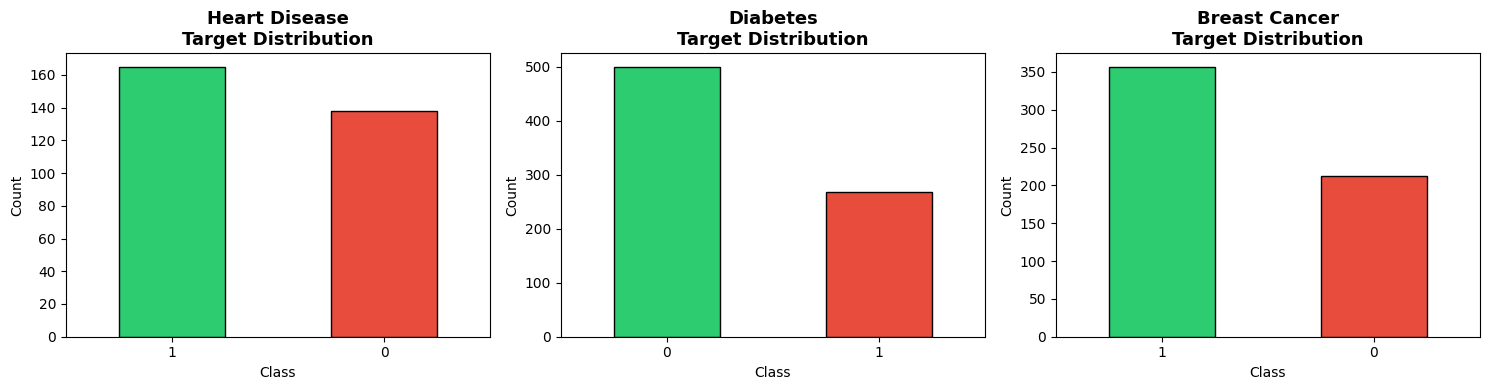

✅ Target distribution plotted!


In [37]:
# Cell 7 - Visualize target distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
datasets = [
    ("Heart Disease", df_heart, df_heart.columns[-1]),
    ("Diabetes", df_diabetes, "Outcome"),
    ("Breast Cancer", df_cancer, "target")
]

for ax, (title, df, target_col) in zip(axes, datasets):
    df[target_col].value_counts().plot(kind='bar', ax=ax, color=['#2ecc71', '#e74c3c'], edgecolor='black')
    ax.set_title(f"{title}\nTarget Distribution", fontsize=13, fontweight='bold')
    ax.set_xlabel("Class")
    ax.set_ylabel("Count")
    ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig("target_distribution.png", dpi=150)
plt.show()
print("✅ Target distribution plotted!")

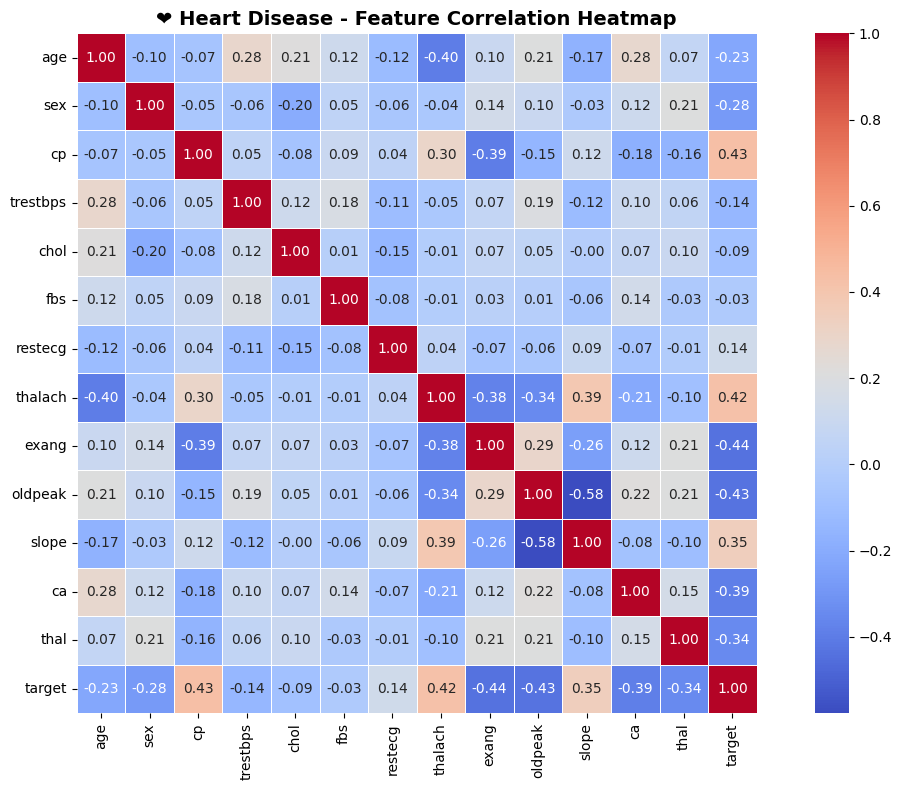

In [38]:
# Cell 8 - Correlation Heatmap (Heart Disease)
plt.figure(figsize=(12, 8))
sns.heatmap(df_heart.corr(), annot=True, fmt=".2f", cmap="coolwarm",
            linewidths=0.5, square=True)
plt.title("❤️ Heart Disease - Feature Correlation Heatmap", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("heart_correlation.png", dpi=150)
plt.show()

In [39]:
# Cell 9 - Universal Preprocessing Function
def preprocess(df, target_col):
    X = df.drop(columns=[target_col])
    y = df[target_col]

    # Handle missing values
    X = X.fillna(X.median())

    # Encode categorical columns if any
    for col in X.select_dtypes(include='object').columns:
        X[col] = LabelEncoder().fit_transform(X[col])

    # Train-Test Split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    # Feature Scaling
    scaler = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train)
    X_test_sc = scaler.transform(X_test)

    return X_train_sc, X_test_sc, y_train, y_test, X.columns.tolist()

# Preprocess all datasets
heart_target = df_heart.columns[-1]
Xh_tr, Xh_te, yh_tr, yh_te, heart_features   = preprocess(df_heart, heart_target)
Xd_tr, Xd_te, yd_tr, yd_te, diab_features    = preprocess(df_diabetes, "Outcome")
Xc_tr, Xc_te, yc_tr, yc_te, cancer_features  = preprocess(df_cancer, "target")

print("✅ All datasets preprocessed!")

✅ All datasets preprocessed!


In [40]:
# Cell 10 - Define classifiers
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "SVM":                 SVC(kernel='rbf', probability=True, random_state=42),
    "Random Forest":       RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost":             XGBClassifier(use_label_encoder=False,
                                         eval_metric='logloss', random_state=42)
}
print("✅ 4 Models ready:", list(models.keys()))

✅ 4 Models ready: ['Logistic Regression', 'SVM', 'Random Forest', 'XGBoost']


In [41]:
# Cell 11-Train and evaluate all combinations
def evaluate_models(models, X_train, X_test, y_train, y_test, dataset_name):
    print(f"\n{'='*60}")
    print(f"  📁 Dataset: {dataset_name}")
    print(f"{'='*60}")
    results = {}
    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]

        acc     = accuracy_score(y_test, y_pred)
        roc_auc = roc_auc_score(y_test, y_prob)
        cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')

        results[name] = {
            'Accuracy': round(acc * 100, 2),
            'ROC-AUC':  round(roc_auc, 4),
            'CV Mean':  round(cv_scores.mean() * 100, 2),
            'CV Std':   round(cv_scores.std() * 100, 2),
            'model':    model,
            'y_pred':   y_pred,
            'y_prob':   y_prob
        }
        print(f"  🔹 {name:<22} Acc: {acc*100:.2f}%  AUC: {roc_auc:.4f}  CV: {cv_scores.mean()*100:.2f}% ± {cv_scores.std()*100:.2f}%")
    return results

# Run evaluation on all 3 datasets
res_heart   = evaluate_models(models, Xh_tr, Xh_te, yh_tr, yh_te, "Heart Disease")
res_diabetes= evaluate_models(models, Xd_tr, Xd_te, yd_tr, yd_te, "Diabetes")
res_cancer  = evaluate_models(models, Xc_tr, Xc_te, yc_tr, yc_te, "Breast Cancer")


  📁 Dataset: Heart Disease
  🔹 Logistic Regression    Acc: 80.33%  AUC: 0.8690  CV: 83.09% ± 4.09%
  🔹 SVM                    Acc: 81.97%  AUC: 0.8831  CV: 80.20% ± 3.88%
  🔹 Random Forest          Acc: 83.61%  AUC: 0.9091  CV: 83.09% ± 4.69%
  🔹 XGBoost                Acc: 80.33%  AUC: 0.8561  CV: 78.95% ± 4.04%

  📁 Dataset: Diabetes
  🔹 Logistic Regression    Acc: 71.43%  AUC: 0.8230  CV: 77.85% ± 1.26%
  🔹 SVM                    Acc: 75.32%  AUC: 0.7924  CV: 75.41% ± 1.66%
  🔹 Random Forest          Acc: 75.97%  AUC: 0.8147  CV: 76.39% ± 3.14%
  🔹 XGBoost                Acc: 73.38%  AUC: 0.8052  CV: 72.64% ± 3.70%

  📁 Dataset: Breast Cancer
  🔹 Logistic Regression    Acc: 98.25%  AUC: 0.9954  CV: 98.02% ± 1.28%
  🔹 SVM                    Acc: 98.25%  AUC: 0.9950  CV: 97.14% ± 1.79%
  🔹 Random Forest          Acc: 95.61%  AUC: 0.9939  CV: 95.38% ± 2.35%
  🔹 XGBoost                Acc: 95.61%  AUC: 0.9901  CV: 96.26% ± 2.15%


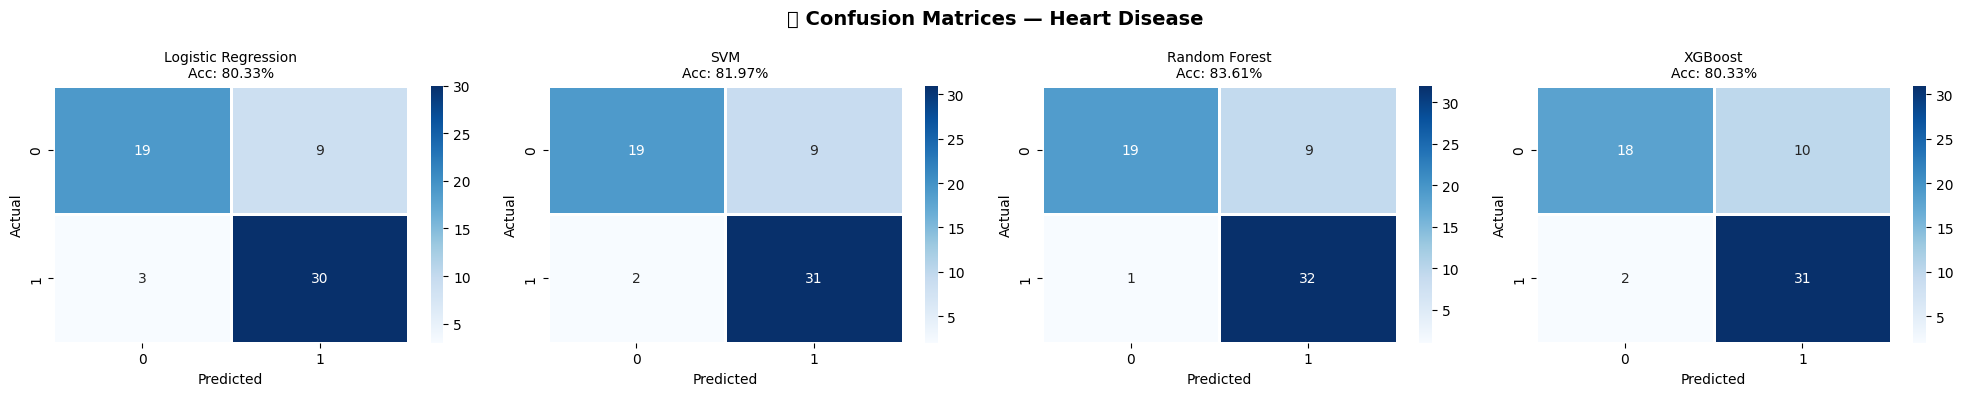

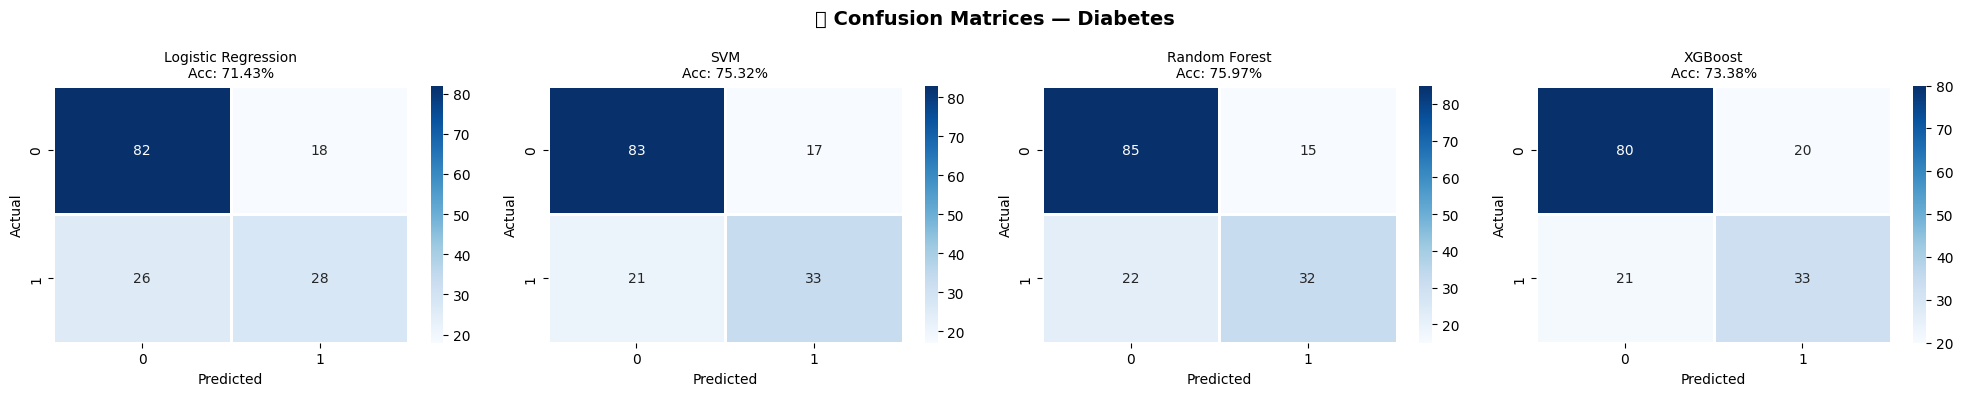

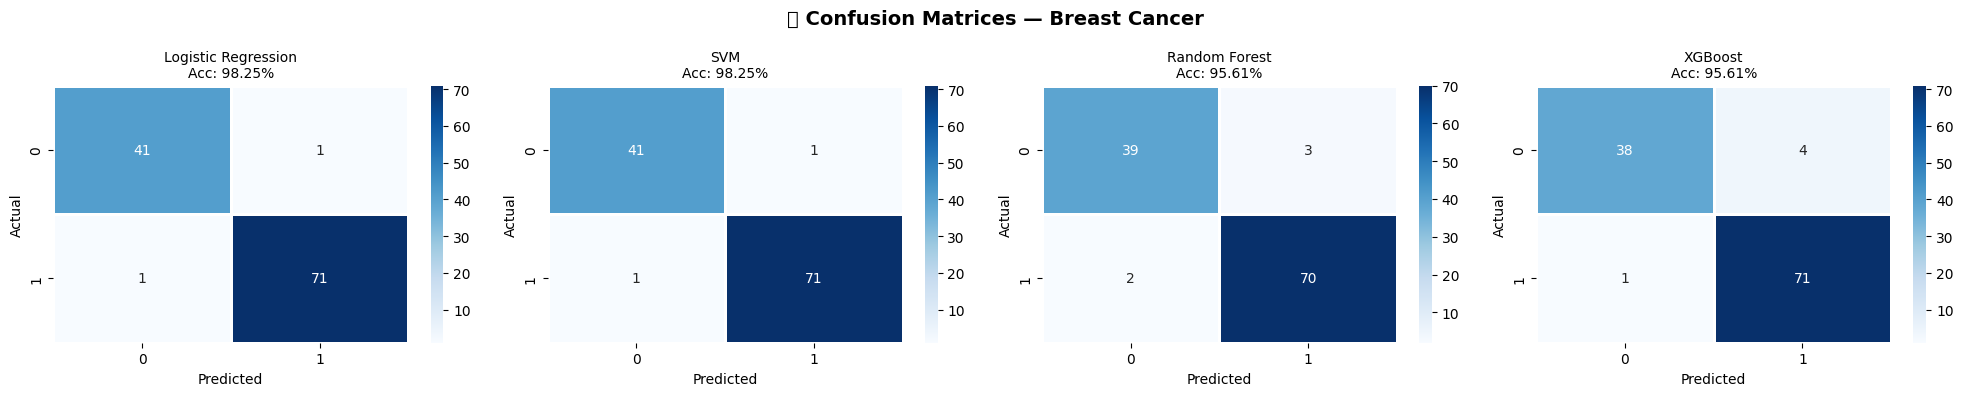

In [42]:
# Cell 12 - Confusion Matrix Grid (all models × 1 dataset at a time)
def plot_confusion_matrices(results, y_test, dataset_name):
    fig, axes = plt.subplots(1, 4, figsize=(20, 4))
    fig.suptitle(f"🔲 Confusion Matrices — {dataset_name}", fontsize=14, fontweight='bold')

    for ax, (name, res) in zip(axes, results.items()):
        cm = confusion_matrix(y_test, res['y_pred'])
        sns.heatmap(cm, annot=True, fmt='d', ax=ax, cmap='Blues',
                    linewidths=1, linecolor='white')
        ax.set_title(f"{name}\nAcc: {res['Accuracy']}%", fontsize=10)
        ax.set_xlabel("Predicted")
        ax.set_ylabel("Actual")

    plt.tight_layout()
    plt.savefig(f"cm_{dataset_name.replace(' ','_')}.png", dpi=150)
    plt.show()

plot_confusion_matrices(res_heart,    yh_te, "Heart Disease")
plot_confusion_matrices(res_diabetes, yd_te, "Diabetes")
plot_confusion_matrices(res_cancer,   yc_te, "Breast Cancer")

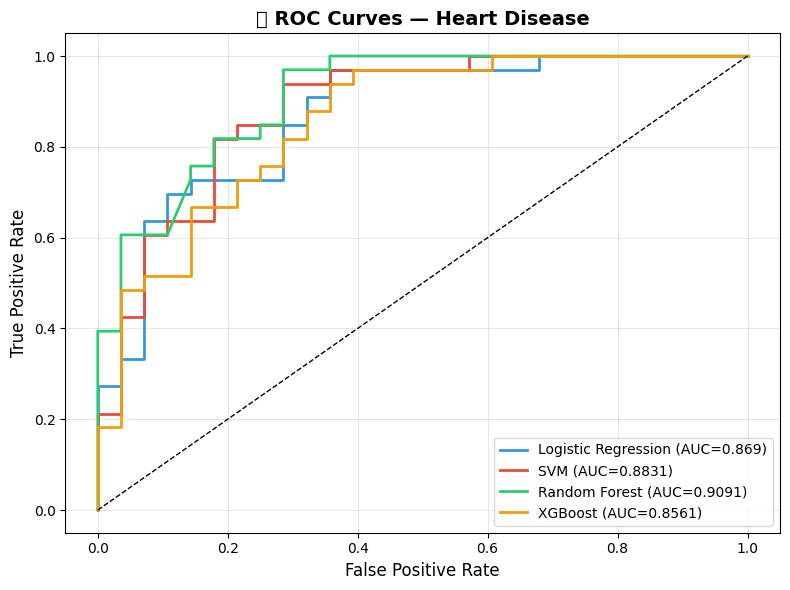

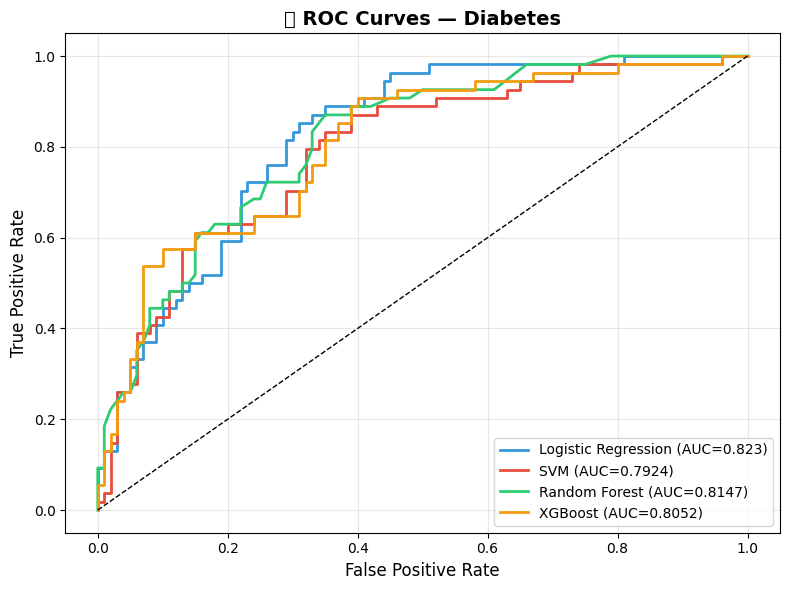

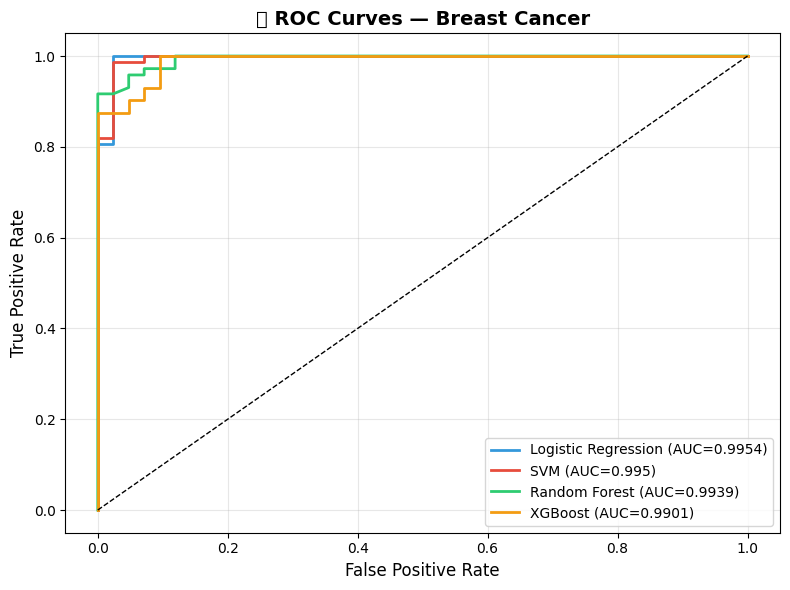

In [43]:
# Cell 13 - ROC Curves
def plot_roc_curves(results, y_test, dataset_name):
    plt.figure(figsize=(8, 6))
    colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']

    for (name, res), color in zip(results.items(), colors):
        fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
        plt.plot(fpr, tpr, label=f"{name} (AUC={res['ROC-AUC']})", color=color, lw=2)

    plt.plot([0,1],[0,1],'k--', lw=1)
    plt.xlabel("False Positive Rate", fontsize=12)
    plt.ylabel("True Positive Rate", fontsize=12)
    plt.title(f"📈 ROC Curves — {dataset_name}", fontsize=14, fontweight='bold')
    plt.legend(loc='lower right', fontsize=10)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"roc_{dataset_name.replace(' ','_')}.png", dpi=150)
    plt.show()

plot_roc_curves(res_heart,    yh_te, "Heart Disease")
plot_roc_curves(res_diabetes, yd_te, "Diabetes")
plot_roc_curves(res_cancer,   yc_te, "Breast Cancer")

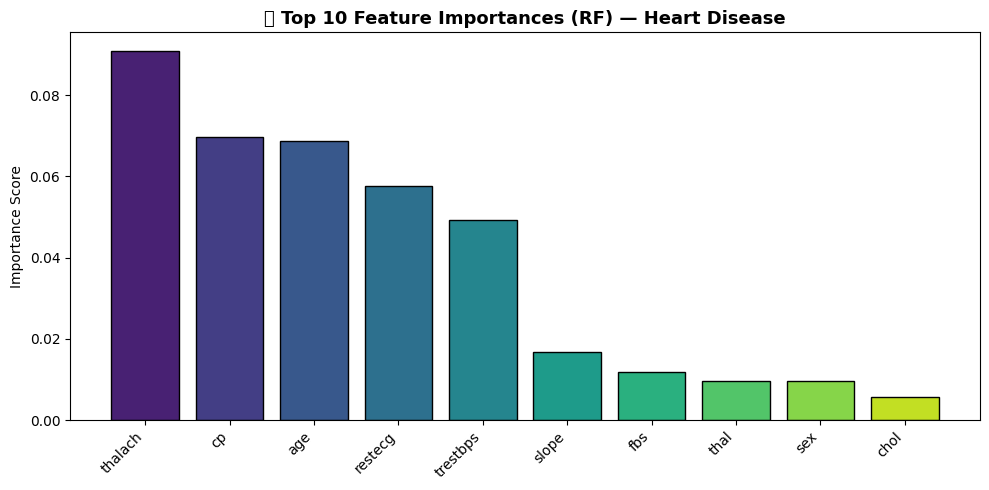

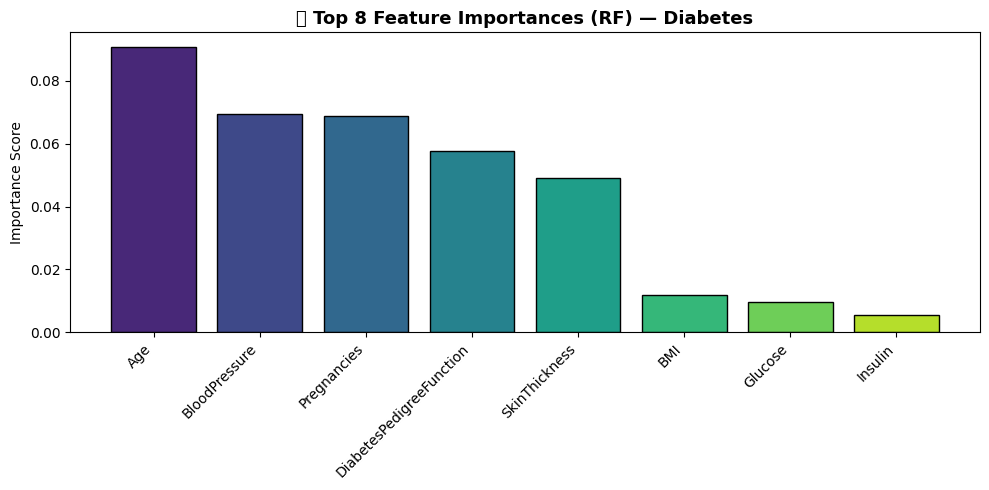

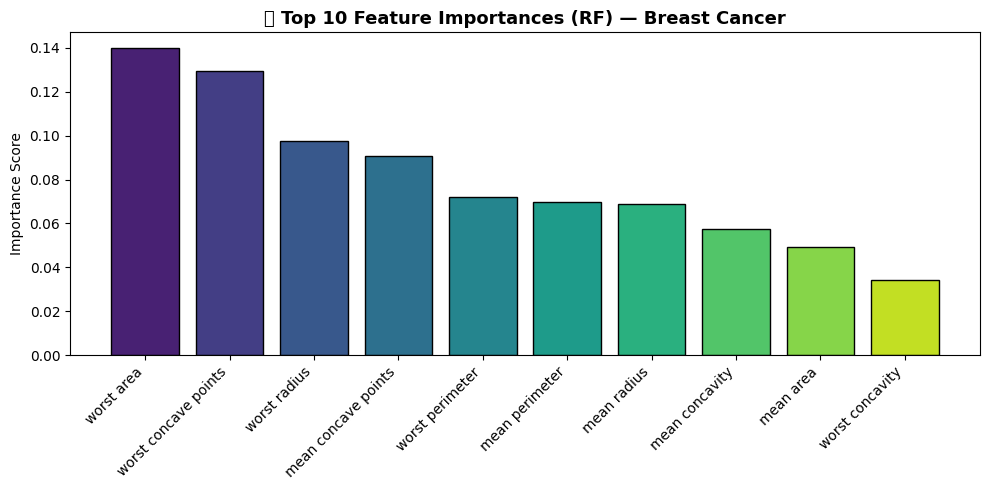

In [44]:
# Cell 14 - Feature Importance
def plot_feature_importance(results, feature_names, dataset_name, top_n=10):
    rf_model = results['Random Forest']['model']
    importances = rf_model.feature_importances_

    # Handle potential mismatch between len(importances) and len(feature_names)
    # If importances has more elements than feature_names, it indicates an inconsistency.
    # We will only consider importances for which we have corresponding feature names.
    if len(importances) > len(feature_names):
        importances = importances[:len(feature_names)]
    # If feature_names has more elements than importances, the indices from importances
    # will still be valid for feature_names, as len(importances) is smaller or equal.

    # Ensure top_n does not exceed the number of available importances
    current_num_features = len(importances)
    actual_top_n = min(top_n, current_num_features)

    # Get indices of top features based on available importances
    indices = np.argsort(importances)[::-1][:actual_top_n]

    plt.figure(figsize=(10, 5))
    plt.bar(range(actual_top_n),
            importances[indices],
            color=sns.color_palette("viridis", actual_top_n),
            edgecolor='black')
    plt.xticks(range(actual_top_n),
               [feature_names[i] for i in indices],
               rotation=45, ha='right')
    plt.title(f"🌲 Top {actual_top_n} Feature Importances (RF) — {dataset_name}",
              fontsize=13, fontweight='bold')
    plt.ylabel("Importance Score")
    plt.tight_layout()
    plt.savefig(f"fi_{dataset_name.replace(' ','_')}.png", dpi=150)
    plt.show()

plot_feature_importance(res_heart,    heart_features,  "Heart Disease")
plot_feature_importance(res_diabetes, diab_features,   "Diabetes")
plot_feature_importance(res_cancer,   cancer_features, "Breast Cancer")

In [45]:
# Cell 15 - Master Summary Table
summary_rows = []
for ds_name, results in [("Heart Disease", res_heart),
                          ("Diabetes",      res_diabetes),
                          ("Breast Cancer", res_cancer)]:
    for model_name, res in results.items():
        summary_rows.append({
            "Dataset":    ds_name,
            "Model":      model_name,
            "Accuracy %": res['Accuracy'],
            "ROC-AUC":    res['ROC-AUC'],
            "CV Mean %":  res['CV Mean'],
            "CV Std %":   res['CV Std']
        })

summary_df = pd.DataFrame(summary_rows)

# Style it
styled = summary_df.style\
    .background_gradient(subset=['Accuracy %', 'ROC-AUC', 'CV Mean %'], cmap='YlGn')\
    .set_caption("🏆 Complete Model Performance Summary")\
    .format({'Accuracy %': '{:.2f}', 'ROC-AUC': '{:.4f}',
             'CV Mean %': '{:.2f}', 'CV Std %': '{:.2f}'})

display(styled)
summary_df.to_csv("model_summary.csv", index=False)
print("✅ Summary saved to model_summary.csv")

,Dataset,Model,Accuracy %,ROC-AUC,CV Mean %,CV Std %
0,Heart Disease,Logistic Regression,80.33,0.8690,83.09,4.09
1,Heart Disease,SVM,81.97,0.8831,80.20,3.88
2,Heart Disease,Random Forest,83.61,0.9091,83.09,4.69
3,Heart Disease,XGBoost,80.33,0.8561,78.95,4.04
4,Diabetes,Logistic Regression,71.43,0.8230,77.85,1.26
5,Diabetes,SVM,75.32,0.7924,75.41,1.66
6,Diabetes,Random Forest,75.97,0.8147,76.39,3.14
7,Diabetes,XGBoost,73.38,0.8052,72.64,3.70
8,Breast Cancer,Logistic Regression,98.25,0.9954,98.02,1.28
9,Breast Cancer,SVM,98.25,0.9950,97.14,1.79


✅ Summary saved to model_summary.csv


In [46]:
# Cell 16 - Best model per dataset
print("\n🏆 BEST MODEL PER DATASET (by Accuracy):\n")
best = summary_df.loc[summary_df.groupby('Dataset')['Accuracy %'].idxmax()]
print(best[['Dataset', 'Model', 'Accuracy %', 'ROC-AUC']].to_string(index=False))


🏆 BEST MODEL PER DATASET (by Accuracy):

      Dataset               Model  Accuracy %  ROC-AUC
Breast Cancer Logistic Regression       98.25   0.9954
     Diabetes       Random Forest       75.97   0.8147
Heart Disease       Random Forest       83.61   0.9091


In [47]:
# Cell 17 - Sample Prediction (Heart Disease)
print("🔮 Predicting for a new patient (Heart Disease)...")

# Create a sample patient — adjust values as needed
sample_patient = pd.DataFrame([
    {
        'age': 55, 'sex': 1, 'cp': 2, 'trestbps': 130,
        'chol': 250, 'fbs': 0, 'restecg': 1, 'thalach': 150,
        'exang': 0, 'oldpeak': 1.5, 'slope': 2, 'ca': 0, 'thal': 2
    }
])

# RE-TRAIN XGBoost specifically for Heart Disease due to shared model instance issue
# This ensures we use a model trained on the correct number of features for heart disease.
heart_xgboost_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
heart_xgboost_model.fit(Xh_tr, yh_tr) # Xh_tr and yh_tr are for Heart Disease

# Use the correctly trained model for prediction
best_model = heart_xgboost_model # Assign the newly trained model to best_model

scaler_h   = StandardScaler()
scaler_h.fit(df_heart.drop(columns=[heart_target]).fillna(df_heart.median()))

sample_scaled = scaler_h.transform(sample_patient)
pred  = best_model.predict(sample_scaled)[0]
prob  = best_model.predict_proba(sample_scaled)[0][1]

print(f"\n  Patient Data: {sample_patient.to_dict('records')[0]}")
print(f"\n  🔴 Prediction : {'Heart Disease Detected' if pred == 1 else '✅ No Heart Disease'}")
print(f"  📊 Probability: {prob*100:.1f}% risk of heart disease")

🔮 Predicting for a new patient (Heart Disease)...

  Patient Data: {'age': 55, 'sex': 1, 'cp': 2, 'trestbps': 130, 'chol': 250, 'fbs': 0, 'restecg': 1, 'thalach': 150, 'exang': 0, 'oldpeak': 1.5, 'slope': 2, 'ca': 0, 'thal': 2}

  🔴 Prediction : Heart Disease Detected
  📊 Probability: 99.8% risk of heart disease
